In [34]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [35]:
# load dataset
sales = pd.read_csv("sales_data_set.csv")
stores = pd.read_csv("stores_data_set.csv")
features = pd.read_csv("Features_data_set.csv")

In [36]:
# Data Understanding (EDA)
# Sale Data
sales.head(2)

,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,05/02/2010,24924.50,False
1,1,1,12/02/2010,46039.49,True


In [37]:
print(sales.shape)

(421570, 5)


In [38]:
sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Store         421570 non-null  int64  
 1   Dept          421570 non-null  int64  
 2   Date          421570 non-null  object 
 3   Weekly_Sales  421570 non-null  float64
 4   IsHoliday     421570 non-null  bool   
dtypes: bool(1), float64(1), int64(2), object(1)
memory usage: 13.3+ MB


In [39]:
sales.describe()

,Store,Dept,Weekly_Sales
count,421570.000000,421570.000000,421570.000000
mean,22.200546,44.260317,15981.258123
std,12.785297,30.492054,22711.183519
min,1.000000,1.000000,-4988.940000
25%,11.000000,18.000000,2079.650000
50%,22.000000,37.000000,7612.030000
75%,33.000000,74.000000,20205.852500
max,45.000000,99.000000,693099.360000


In [40]:
sales.isna().sum()

Store           0
Dept            0
Date            0
Weekly_Sales    0
IsHoliday       0
dtype: int64

In [41]:
sales.duplicated().sum()

np.int64(0)

In [42]:
stores.head()

,Store,Type,Size
0,1,A,151315
1,2,A,202307
2,3,B,37392
3,4,A,205863
4,5,B,34875


In [43]:
print(stores.shape)
print(stores.info())
print(stores.describe())
print(stores.isna().sum())
print(stores.duplicated().sum())

(45, 3)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45 entries, 0 to 44
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Store   45 non-null     int64 
 1   Type    45 non-null     object
 2   Size    45 non-null     int64 
dtypes: int64(2), object(1)
memory usage: 1.2+ KB
None
           Store           Size
count  45.000000      45.000000
mean   23.000000  130287.600000
std    13.133926   63825.271991
min     1.000000   34875.000000
25%    12.000000   70713.000000
50%    23.000000  126512.000000
75%    34.000000  202307.000000
max    45.000000  219622.000000
Store    0
Type     0
Size     0
dtype: int64
0


In [44]:
print(features.head())
print(features.shape)
print(features.info())
print(features.describe())
print(features.isna().sum())
print(features.duplicated().sum())

   Store        Date  Temperature  Fuel_Price  MarkDown1  MarkDown2  \
0      1  05/02/2010        42.31       2.572        NaN        NaN   
1      1  12/02/2010        38.51       2.548        NaN        NaN   
2      1  19/02/2010        39.93       2.514        NaN        NaN   
3      1  26/02/2010        46.63       2.561        NaN        NaN   
4      1  05/03/2010        46.50       2.625        NaN        NaN   

   MarkDown3  MarkDown4  MarkDown5         CPI  Unemployment  IsHoliday  
0        NaN        NaN        NaN  211.096358         8.106      False  
1        NaN        NaN        NaN  211.242170         8.106       True  
2        NaN        NaN        NaN  211.289143         8.106      False  
3        NaN        NaN        NaN  211.319643         8.106      False  
4        NaN        NaN        NaN  211.350143         8.106      False  
(8190, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8190 entries, 0 to 8189
Data columns (total 12 columns):
 #   Column

In [45]:
sales['Date'] = pd.to_datetime(sales['Date'], dayfirst=True)

In [46]:
features['Date'] = pd.to_datetime(features['Date'], dayfirst=True)

In [47]:
sales.drop_duplicates(inplace=True)
stores.drop_duplicates(inplace=True)
features.drop_duplicates(inplace=True)

In [48]:
df = pd.merge(sales, stores, on='Store',how='left')

In [49]:
df = pd.merge(df, features, on=['Store','Date','IsHoliday'],how='left')

In [50]:
df.shape

(421570, 16)

In [51]:
# Feature Engineering
df['Year'] = df['Date'].dt.year

In [52]:
df['Month'] = df['Date'].dt.month_name()
df['Month_number'] = df['Date'].dt.month
df['Quarter'] = df['Date'].dt.quarter
df['Week'] = df['Date'].dt.isocalendar().week
df['Day_Name'] = df['Date'].dt.day_name()

In [53]:
# KPI Calculations
total_sales = df['Weekly_Sales'].sum()
average_sale = df['Weekly_Sales'].mean()
min_sale = df['Weekly_Sales'].min()
max_sale = df['Weekly_Sales'].max()
number_of_stores = df['Store'].nunique()
number_of_dept = df['Dept'].nunique()

print("Total Sales          :", total_sales)
print("Average Weekly Sales :",average_sale)
print("Maximum Weekly Sales :",max_sale)
print("Minimum Weekly Sales :",min_sale)
print("Total Stores         :",number_of_stores)
print("Total Departments    :",number_of_dept)

Total Sales          : 6737218987.110001
Average Weekly Sales : 15981.258123467042
Maximum Weekly Sales : 693099.36
Minimum Weekly Sales : -4988.94
Total Stores         : 45
Total Departments    : 81


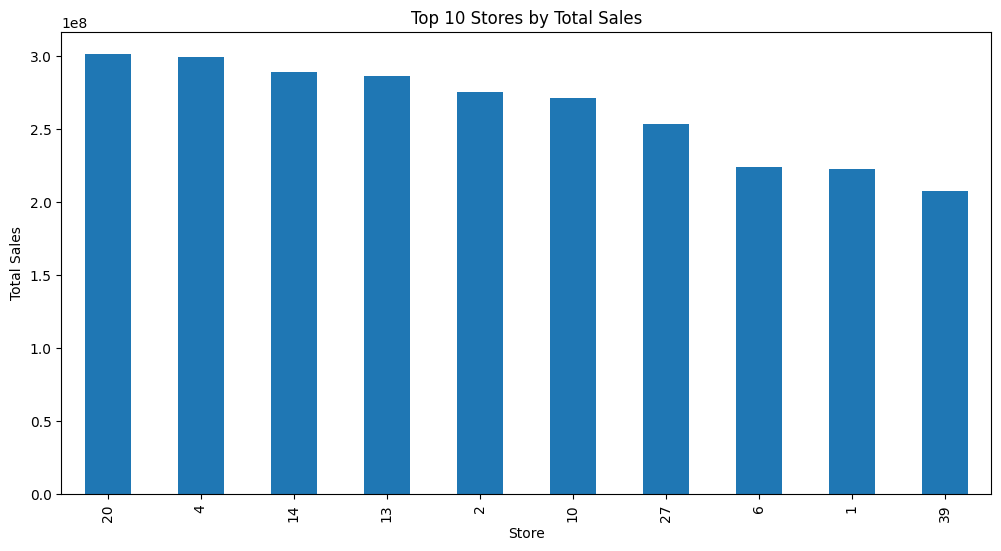

In [54]:
# Business Questions
# 1. which stores generate highest sales?
store_sales = (df.groupby('Store')['Weekly_Sales'].sum().sort_values(ascending=False).head(10))

plt.figure(figsize=(12,6))
store_sales.plot(kind='bar')

plt.title("Top 10 Stores by Total Sales")
plt.xlabel("Store")
plt.ylabel("Total Sales")
plt.show()

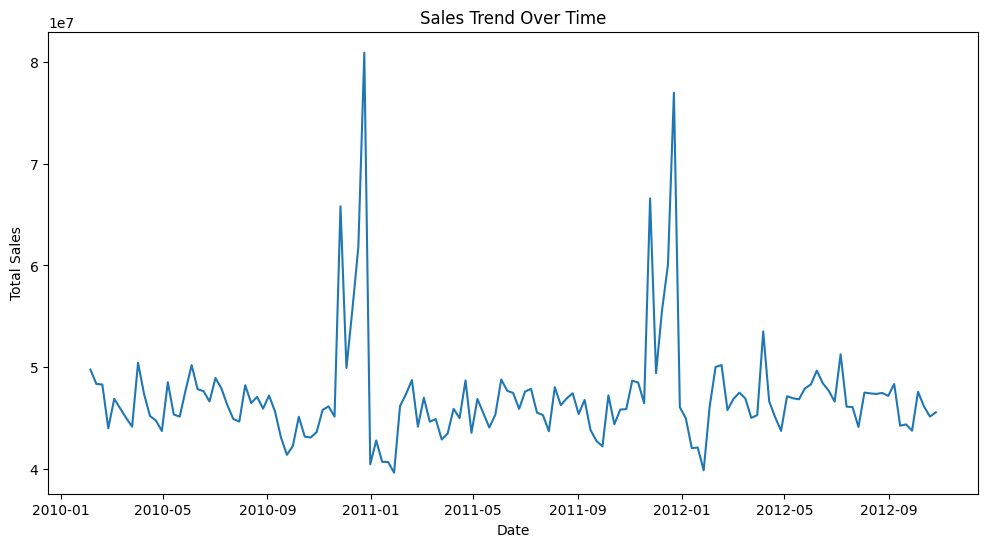

In [55]:
# 2. How do sales change over time?
sales_trend = (df.groupby("Date")['Weekly_Sales'].sum())

plt.figure(figsize=(12,6))

plt.plot(sales_trend.index, sales_trend.values)

plt.title("Sales Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.show()

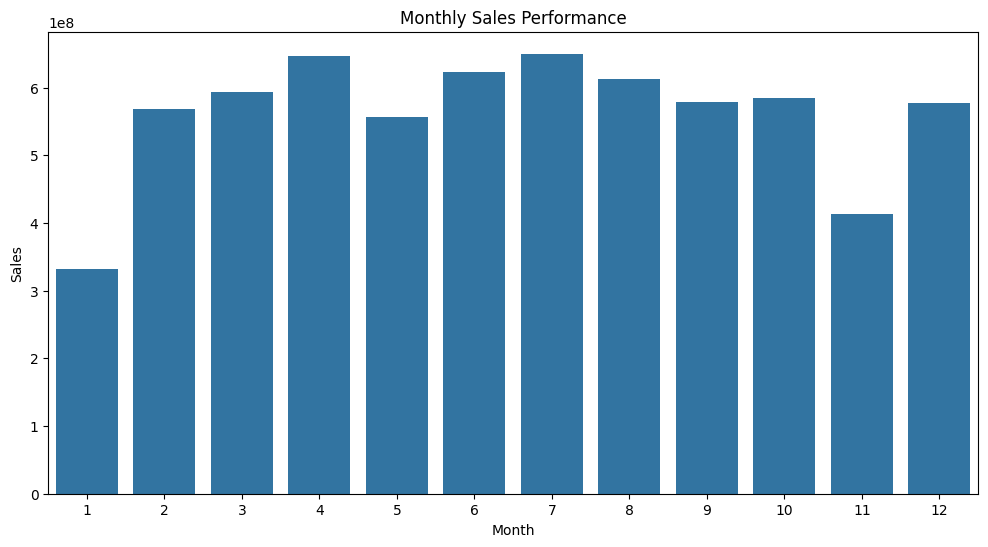

In [56]:
# 4. which month perform best
monthly_sales = (df.groupby('Month_number')['Weekly_Sales'].sum())

plt.figure(figsize=(12,6))

sns.barplot(x=monthly_sales.index, y=monthly_sales.values)

plt.title("Monthly Sales Performance")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.show()

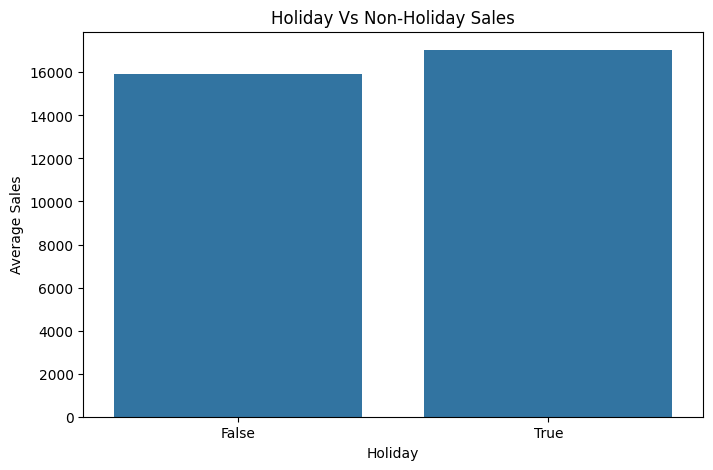

In [57]:
# 5. Do holidays increase sales?
holiday_sales = (df.groupby('IsHoliday')['Weekly_Sales'].mean())

plt.figure(figsize=(8,5))

sns.barplot(x=holiday_sales.index, y=holiday_sales.values)

plt.title("Holiday Vs Non-Holiday Sales")
plt.xlabel("Holiday")
plt.ylabel("Average Sales")
plt.show()

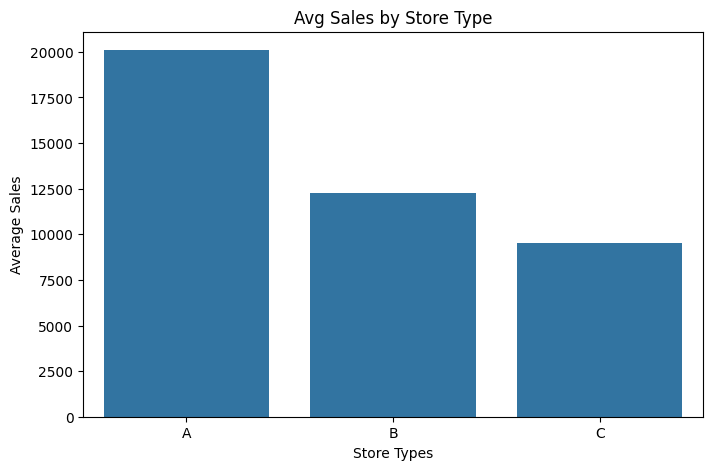

In [58]:
# 6. Which Store type perform best?
Store_type_sales = (df.groupby('Type')['Weekly_Sales'].mean())

plt.figure(figsize=(8,5))

sns.barplot(x=Store_type_sales.index, y=Store_type_sales.values)

plt.title("Avg Sales by Store Type")
plt.xlabel("Store Types")
plt.ylabel("Average Sales")
plt.show()

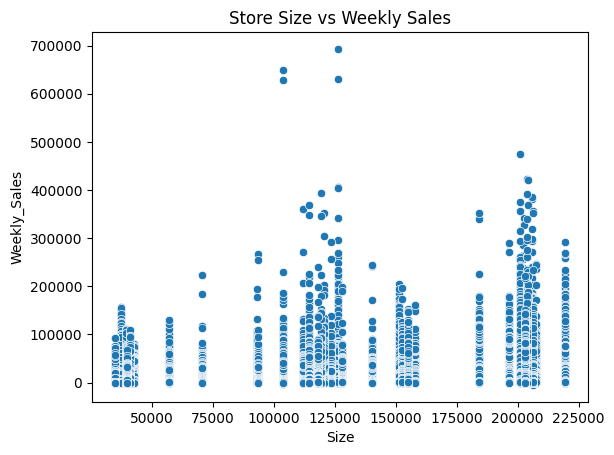

In [59]:
# Does Store Size impact sales

sns.scatterplot(data=df, x= 'Size', y='Weekly_Sales')
plt.title("Store Size vs Weekly Sales")
plt.show()


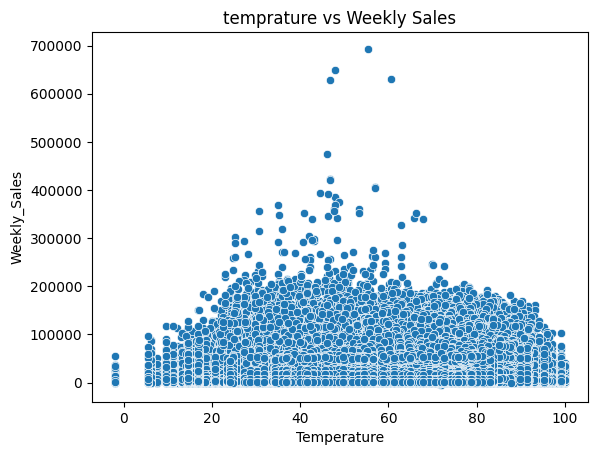

In [60]:
# Does temprature Size impact sales

sns.scatterplot(data=df, x= 'Temperature', y='Weekly_Sales')
plt.title("temprature vs Weekly Sales")
plt.show()


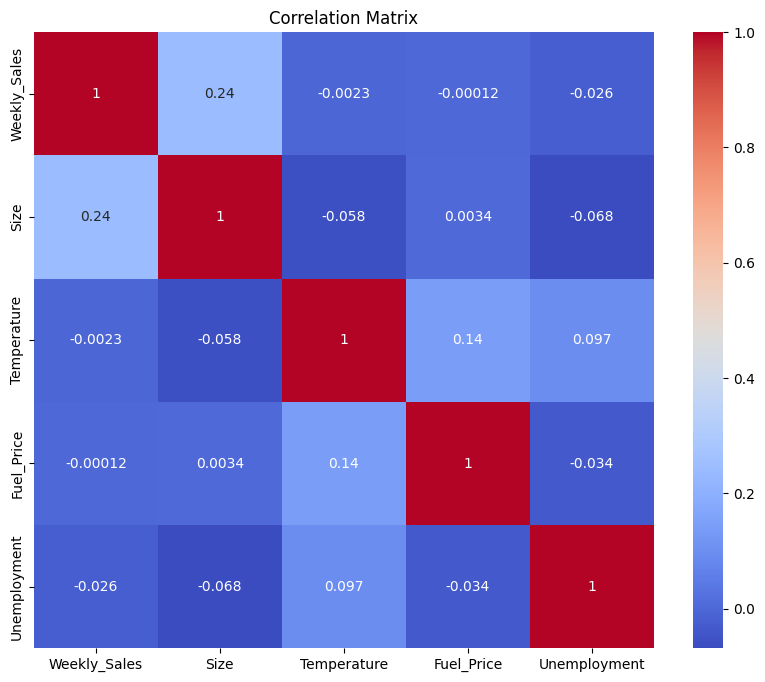

In [61]:
# which features influence sales most?
corr_columns = ['Weekly_Sales','Size','Temperature','Fuel_Price','Unemployment']
correlation = df[corr_columns].corr()

plt.figure(figsize=(10,8))
sns.heatmap(correlation, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

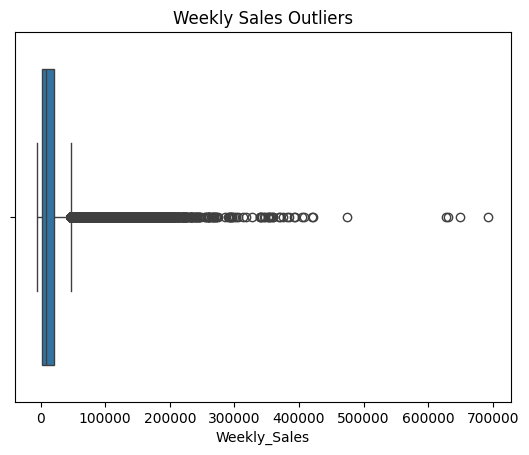

In [62]:
sns.boxplot(x=df['Weekly_Sales'])
plt.title('Weekly Sales Outliers')
plt.show()

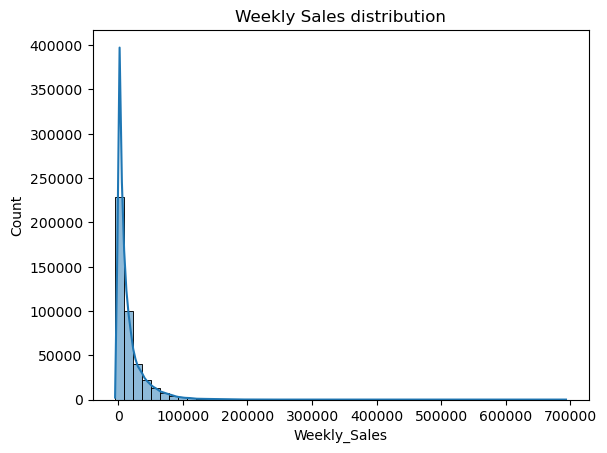

In [40]:
sns.histplot(df['Weekly_Sales'], bins=50,kde=True)
plt.title("Weekly Sales distribution")
plt.show()